In [ ]:
#Load dataset
import pandas as pd
import numpy as np

data_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/data_train.csv')
data_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/data_test.csv')

**LSTM**

***Melakukan encoding untuk data sentimen***

```
negatif = 0
netral = 1
positif = 2
```


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

y_train = data_train['sentimen']
y_train_encode = encoder.fit_transform(y_train)

y_test = data_test['sentimen']
y_test_encode = encoder.transform(y_test)

Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data_train["clean_tweet"])

x_train_seq = tokenizer.texts_to_sequences(data_train["clean_tweet"])
x_test_seq = tokenizer.texts_to_sequences(data_test["clean_tweet"])

Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100
x_train_pad = pad_sequences(x_train_seq, maxlen=max_len)
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len)

**Build and Train LSTM**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

vocab_size = 5000
max_len = 100

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile Model

In [ ]:
from tensorflow.keras.optimizers import AdamW

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=AdamW(learning_rate=0.001),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Menggunakan Early **Stopper**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = lstm_model.fit(
    x_train_pad,
    y_train_encode,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.3772 - loss: 1.0866 - val_accuracy: 0.4811 - val_loss: 1.0216
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.5633 - loss: 0.9700 - val_accuracy: 0.5704 - val_loss: 0.9285
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.7576 - loss: 0.6455 - val_accuracy: 0.5670 - val_loss: 0.9691
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - accuracy: 0.8513 - loss: 0.4721 - val_accuracy: 0.5945 - val_loss: 1.1589
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.9293 - loss: 0.2176 - val_accuracy: 0.5945 - val_loss: 1.3190


In [ ]:
# Prediksi
import numpy as np
y_pred_prob = lstm_model.predict(x_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


              precision    recall  f1-score   support

           0       0.51      0.80      0.62       115
           1       0.58      0.62      0.60       118
           2       0.69      0.29      0.41       130

    accuracy                           0.56       363
   macro avg       0.59      0.57      0.54       363
weighted avg       0.60      0.56      0.54       363



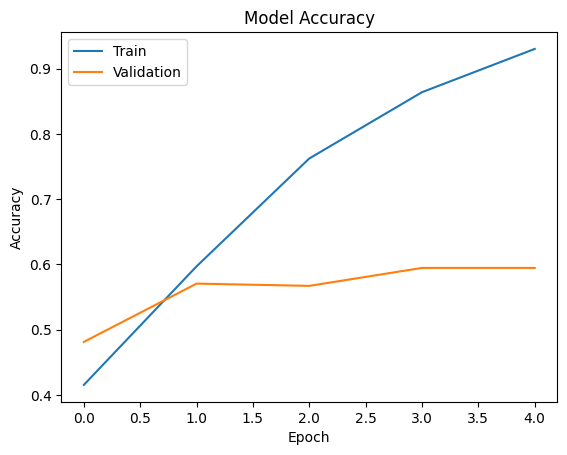

In [ ]:
# Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_encode, y_pred))
confusion_matrix(y_test_encode, y_pred)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()